# Evidencia de clase - 02/09/26

## Ruido de cuantizacion (ADC)

Se genera una senoidal contaminada con ruido analogico, se la cuantiza con un ADC de
B bits y se comparan en el dominio de la frecuencia:

- el espectro de la señal analogica ruidosa (`xxr`)
- el espectro del ruido de cuantizacion (`nq = xxq - xxr`)
- el espectro de la señal cuantizada (`xxq`)

El objetivo es ver el piso de ruido que introduce el ADC y verificar que el error de
cuantizacion se distribuye de manera uniforme entre -q/2 y +q/2, con varianza q^2/12.


In [10]:


import numpy as np
import matplotlib.pyplot as plt

plt.close('all')


In [11]:

fs = 1000              # frecuencia de muestreo (Hz)
N  = 1000              # cantidad de muestras
ts = 1/fs              # tiempo de muestreo
df = fs/N              # resolucion espectral (Hz)

vmax = np.sqrt(2)      # amplitud -> potencia media de la senoidal = 1 W (0 dB)
dc   = 0               # offset
ff   = 10*df           # frecuencia de la senoidal (10 bines -> sin desparramo)
ph   = 0               # fase (rad)


In [12]:
#%% ---------------- SEÑAL + RUIDO ANALOGICO --------------------

tt = np.arange(0, N/fs, ts)          # vector de tiempo
xx = dc + vmax * np.sin(2*np.pi*ff*tt + ph)    # senoidal "analogica"

# ruido analogico: lo defino como kn veces la potencia del ruido de cuantizacion
# (kn = 1 -> ambos ruidos parejos ; kn > 1 -> domina el ruido analogico)
kn = 10

pot_ruido = kn * (2*2/(2**4))**2 / 12          # q^2/12 con los datos del ADC de abajo
ruido = np.random.normal(0, np.sqrt(pot_ruido), N)

xxr = xx + ruido       # señal analogica contaminada con ruido


In [13]:
#%% -------------------------- ADC ------------------------------

B   = 4                 # Bits
Vfs = 2                 # V de referencia del ADC
qq  = 2*Vfs/(2**B)      # paso de cuantizacion (tamaño del escalon)

print("Paso de cuantizacion q = {:.4f} V".format(qq))


Paso de cuantizacion q = 0.2500 V


In [14]:
#%% ------------------ MODULO DEL ESPECTRO -----------------------

# vector de frecuencia
frec = np.arange(N//2) * fs/N

xxtr = (1/N) * np.fft.fft(xxr)             # fft normalizada de xxr
modulo_xxtr = np.abs(xxtr)
modulo_xxtr_db = 10 * np.log10( 2*(np.abs(modulo_xxtr[:N//2]) ) ** 2 )   # pone 0dB como referencia de 1W de potencia


# espectro de fase (con Ruido)
ang_tr = np.fft.fft(xxr)
fase_r = np.angle(ang_tr)/(2*np.pi)
# plt.title("Espectro Fase Con ruido")
# plt.plot(fase_r, color="gray")
# plt.show()


In [15]:
#%% ----------------------- CUANTIZACION -------------------------

xxq = np.round(xxr/qq)*qq       # señal cuantizada
nq  = xxq - xxr                 # ruido consecuencia de la cuantizacion (señal cuantizada - señal original)
nqtr = (1/N) * np.fft.fft(nq)
modulo_nqtr_db = 10 * np.log10(2*(np.abs(nqtr[:N//2]) ) ** 2)


xxqtr = (1/N) * np.fft.fft(xxq)     # tr de la señal cuantizada
modulo_xxqtr_db = 10 * np.log10(2*(np.abs(xxqtr[:N//2]) ) ** 2)   # en dB


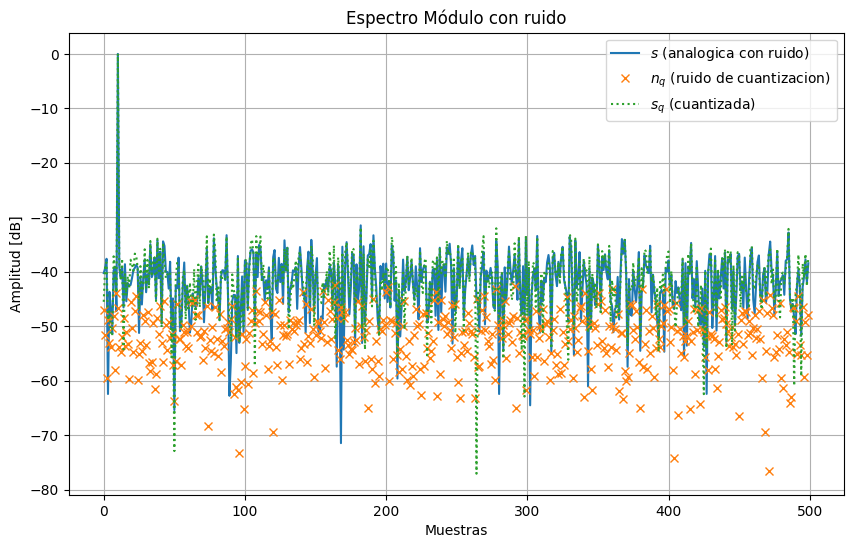

In [16]:
#%% ------------- GRAFICO DE MODULO DEL ESPECTRO -----------------

plt.figure(figsize=(10, 6))

plt.plot(frec, modulo_xxtr_db, label='$s$ (analogica con ruido)')
plt.plot(frec, modulo_nqtr_db, 'x', label='$n_q$ (ruido de cuantizacion)')
plt.plot(frec, modulo_xxqtr_db, ':', label='$s_q$ (cuantizada)')

plt.title("Espectro Módulo con ruido")
plt.ylabel("Amplitud [dB]")
plt.xlabel("Muestras")
plt.legend()
plt.grid(True)
plt.show()


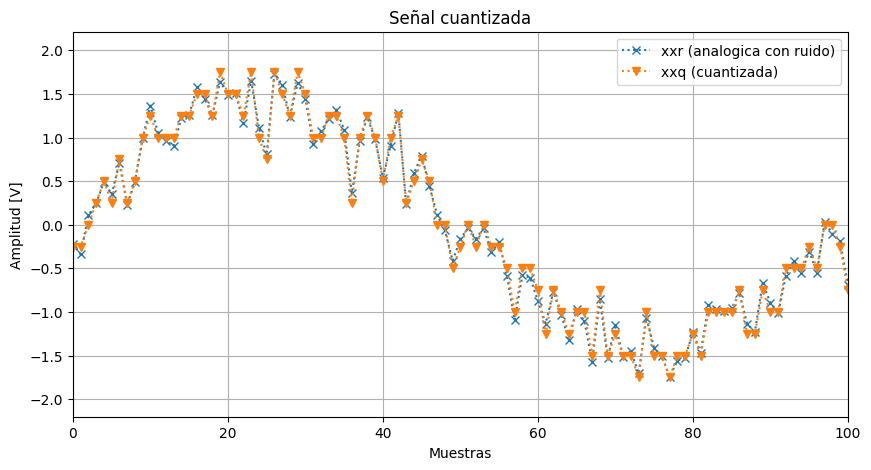

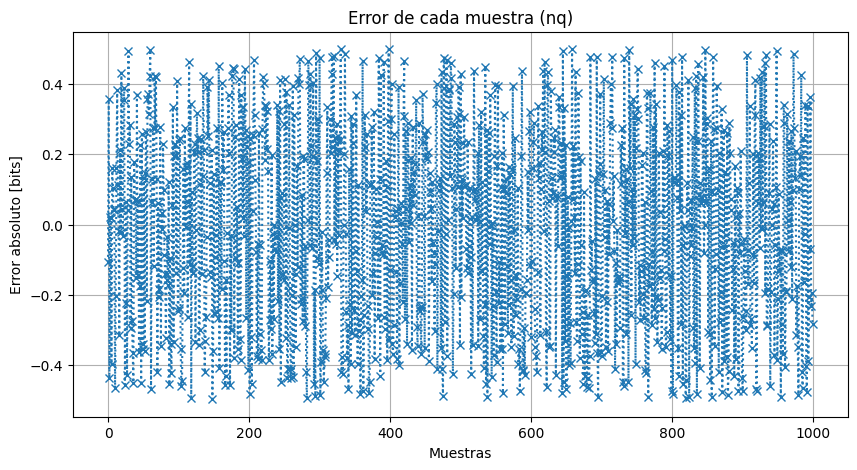

In [17]:
#%% --------------- SEÑAL ANALOGICA VS CUANTIZADA ----------------

plt.figure(figsize=(10, 5))
plt.plot(xxr, ':x', label='xxr (analogica con ruido)')
plt.plot(xxq, ':v', label='xxq (cuantizada)')
plt.xlabel("Muestras")
plt.ylabel("Amplitud [V]")
plt.title("Señal cuantizada")
plt.xlim(0, 100)
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.title("Error de cada muestra (nq)")
plt.xlabel("Muestras")
plt.ylabel("Error absoluto [bits]")
plt.plot(nq/qq, ':x')
plt.grid(True)
plt.show()


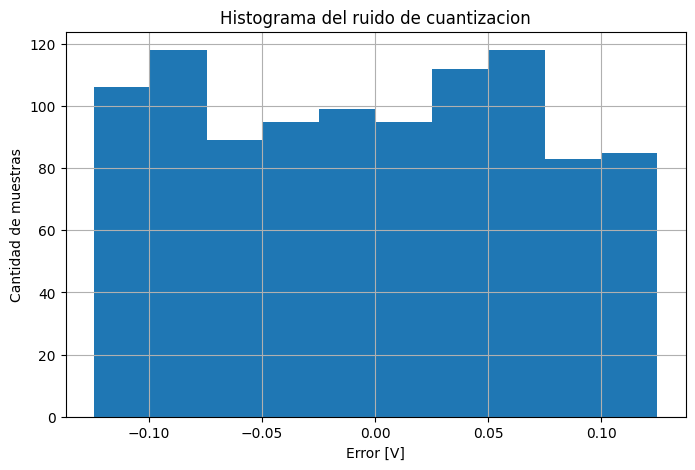

Varianza medida   : 0.005115
Varianza teorica  : 0.005208


In [18]:
#%% ------------ DISTRIBUCION DEL RUIDO DE CUANTIZACION ----------
# equivalente al "%varexp --hist nq" de Spyder

plt.figure(figsize=(8, 5))
plt.hist(nq, bins=10)
plt.title("Histograma del ruido de cuantizacion")
plt.xlabel("Error [V]")
plt.ylabel("Cantidad de muestras")
plt.grid(True)
plt.show()

print("Varianza medida   : {:.6f}".format(np.var(nq)))
print("Varianza teorica  : {:.6f}".format(qq**2/12))


---

# Version vista en clase (TS2 compartido en pantalla)

Misma idea pero con la potencia del ruido analogico atada a la del ruido de cuantizacion
mediante la constante `k_n`:

$$P_q = \frac{q^2}{12} \qquad P_n = k_n \cdot P_q$$
rac{q^2}{12} \qquad P_n = k_n \cdot P_q$$

Se apoya en dos funciones auxiliares (`mi_funcion_seno` y `mi_fft`) y normaliza el espectro
en dB respecto del maximo, asi el pico de la senoidal queda en 0 dB y los pisos de ruido se
leen directamente como cuanto estan por debajo de la señal.


In [19]:
#%% ---------------------- FUNCIONES AUXILIARES ------------------

def mi_funcion_seno(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    """Genera una senoidal. Devuelve (tiempo, señal)."""
    t = np.arange(nn)/fs
    x = dc + vmax * np.sin(2*np.pi*ff*t + ph)
    return t, x


def mi_fft(x, fs=fs):
    """FFT normalizada, medio espectro. Devuelve (frecuencia, modulo)."""
    nn = len(x)
    X = np.fft.fft(x)/nn
    freq = np.arange(nn//2) * fs/nn
    return freq, np.abs(X[:nn//2])


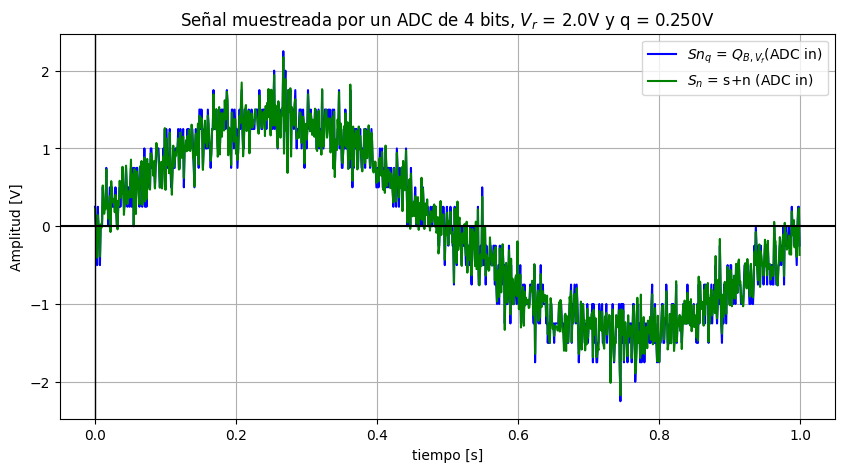

In [20]:
#%% ------------------- ADC + RUIDO ANALOGICO --------------------

t, s = mi_funcion_seno(vmax=np.sqrt(2), ff=fs/N)   # 1 ciclo en la ventana

n_bits = 4
k_n = 10                                   # P_n = k_n * P_q
Vfs = 2
q = (2*Vfs)/(np.power(2, n_bits))          # paso de cuantizacion
P_q = q**2/12                              # potencia del ruido de cuantizacion
P_n = k_n * P_q                            # potencia del ruido analogico
sigma = np.sqrt(P_n)
n = np.random.normal(scale=sigma, size=len(t))

sn = s + n                                 # entrada del ADC
sn_cuantizada = np.round(sn/q)*q           # salida del ADC

titulo = "ADC de {:d} bits, $V_r$ = {:.1f}V y q = {:.3f}V".format(n_bits, Vfs, q)

plt.figure(1, figsize=(10, 5))
plt.plot(t, sn_cuantizada, color="blue",  label="$Sn_q$ = $Q_{B,V_f}$(ADC in)")
plt.plot(t, sn,            color="green", label="$S_n$ = s+n (ADC in)")
plt.title("Señal muestreada por un " + titulo)
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.axhline(0, color="black")
plt.axvline(0, color="black", linewidth=1)
plt.legend()
plt.show()


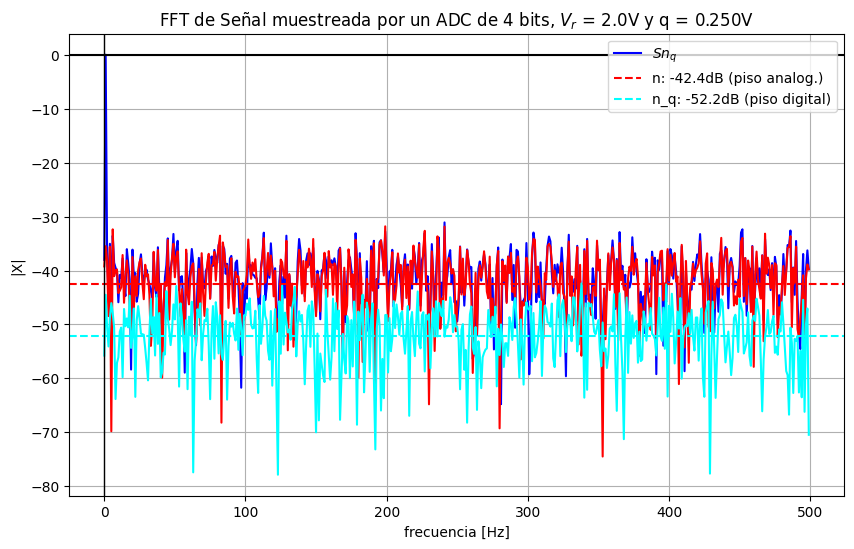

In [21]:
#%% --------------- ESPECTROS NORMALIZADOS EN dB -----------------

freq, sn_fft_abs = mi_fft(sn)
ref = np.max(sn_fft_abs)                   # referencia: pico de la senoidal -> 0 dB

sn_fft_dB = 20 * np.log10(sn_fft_abs/ref)

freq, sn_cuantizada_fft_abs = mi_fft(sn_cuantizada)
sn_cuantizada_fft_dB = 20 * np.log10(sn_cuantizada_fft_abs/ref)

freq, n_fft_abs = mi_fft(n)
n_fft_dB = 20 * np.log10(n_fft_abs/ref)

n_q = sn_cuantizada - sn                   # error de cuantizacion
freq, n_q_fft_abs = mi_fft(n_q)
n_q_fft_dB = 20 * np.log10(n_q_fft_abs/ref)


plt.figure(2, figsize=(10, 6))
plt.plot(freq, sn_cuantizada_fft_dB, color="blue", label="$Sn_q$")
plt.plot(freq, n_fft_dB, linestyle="-", color="red")
plt.axhline(np.mean(n_fft_dB), color="red", linestyle="--",
            label=f"n: {np.mean(n_fft_dB):.1f}dB (piso analog.)")
plt.plot(freq, n_q_fft_dB, color="cyan")
plt.axhline(np.mean(n_q_fft_dB), color="cyan", linestyle="--",
            label=f"n_q: {np.mean(n_q_fft_dB):.1f}dB (piso digital)")

plt.legend()
plt.title("FFT de Señal muestreada por un " + titulo)
plt.ylabel("|X|")
plt.xlabel("frecuencia [Hz]")
plt.grid()
plt.axhline(0, color="black")
plt.axvline(0, color="black", linewidth=1)
plt.show()


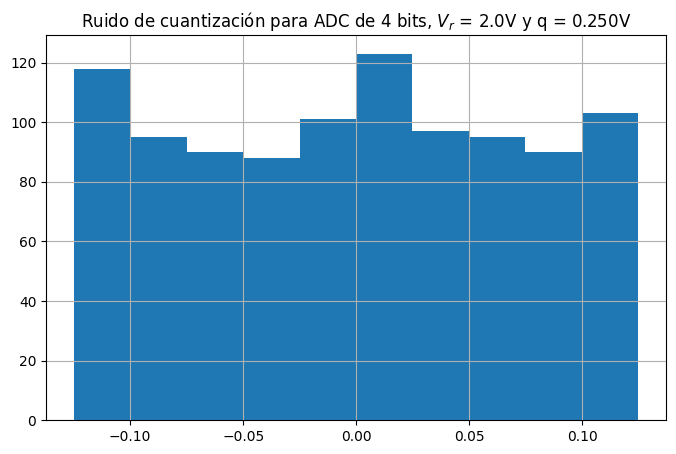

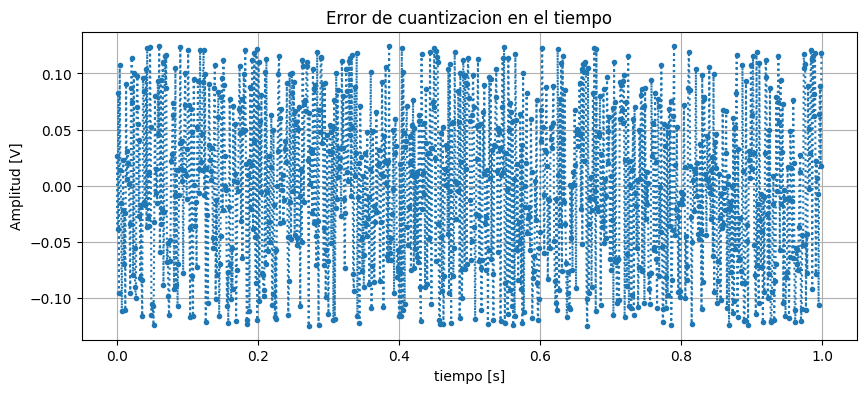

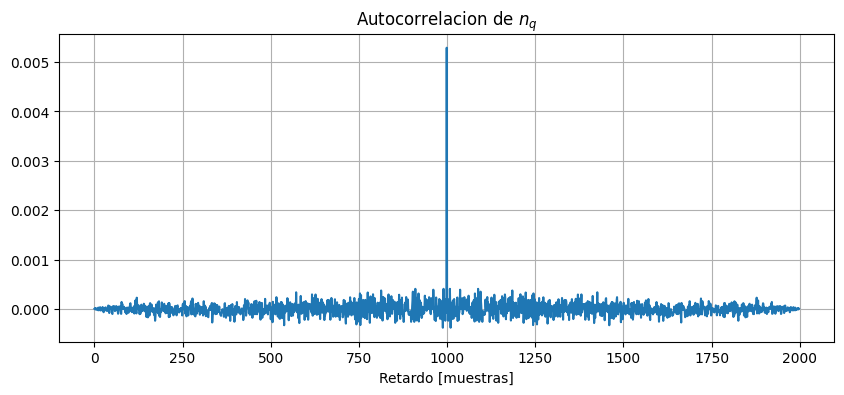

R[0] medida    : 0.005288
q^2/12 teorica : 0.005208


In [22]:
#%% ------------- DISTRIBUCION Y CORRELACION DE n_q ---------------

plt.figure(3, figsize=(8, 5))
plt.hist(n_q)
plt.title("Ruido de cuantización para " + titulo)
plt.grid()
plt.show()

correlacion = np.correlate(n_q, n_q, "full")/N

plt.figure(4, figsize=(10, 4))
plt.plot(t, n_q, ":.")
plt.title("Error de cuantizacion en el tiempo")
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

plt.figure(5, figsize=(10, 4))
plt.plot(correlacion)
plt.title("Autocorrelacion de $n_q$")
plt.xlabel("Retardo [muestras]")
plt.grid()
plt.show()

print("R[0] medida    : {:.6f}".format(np.max(correlacion)))
print("q^2/12 teorica : {:.6f}".format(P_q))


## Lo que se discutio: el efecto de `k_n`

En clase se corrio el mismo codigo bajando `k_n` de 10 a 1/100. La conclusion es que el
modelo de "ruido de cuantizacion blanco, uniforme e incorrelado" **no siempre vale**:

- **`k_n = 10`** (ruido analogico >> escalon del ADC): el ruido analogico hace de *dither*,
  desparrama la señal entre varios escalones y el error `n_q` sale uniforme entre -q/2 y
  +q/2, con autocorrelacion en forma de delta y piso plano en el espectro.
- **`k_n = 1/100`** (ruido analogico << escalon del ADC): la entrada casi no se mueve
  dentro de un escalon, asi que `n_q` deja de ser aleatorio y pasa a ser una funcion
  deterministica de la señal. En el grafico temporal se ve el patron correlacionado con la
  senoidal (los "grumos" cerca de los picos, donde la señal cambia mas lento) y en el
  espectro aparecen armonicos en vez de un piso plano.


k_n = 10     | var(n_q)/(q^2/12) = 1.08 | max|R[k!=0]| = 0.09 | pico-piso = 12.1 dB
k_n = 0.01   | var(n_q)/(q^2/12) = 1.15 | max|R[k!=0]| = 0.83 | pico-piso = 25.6 dB


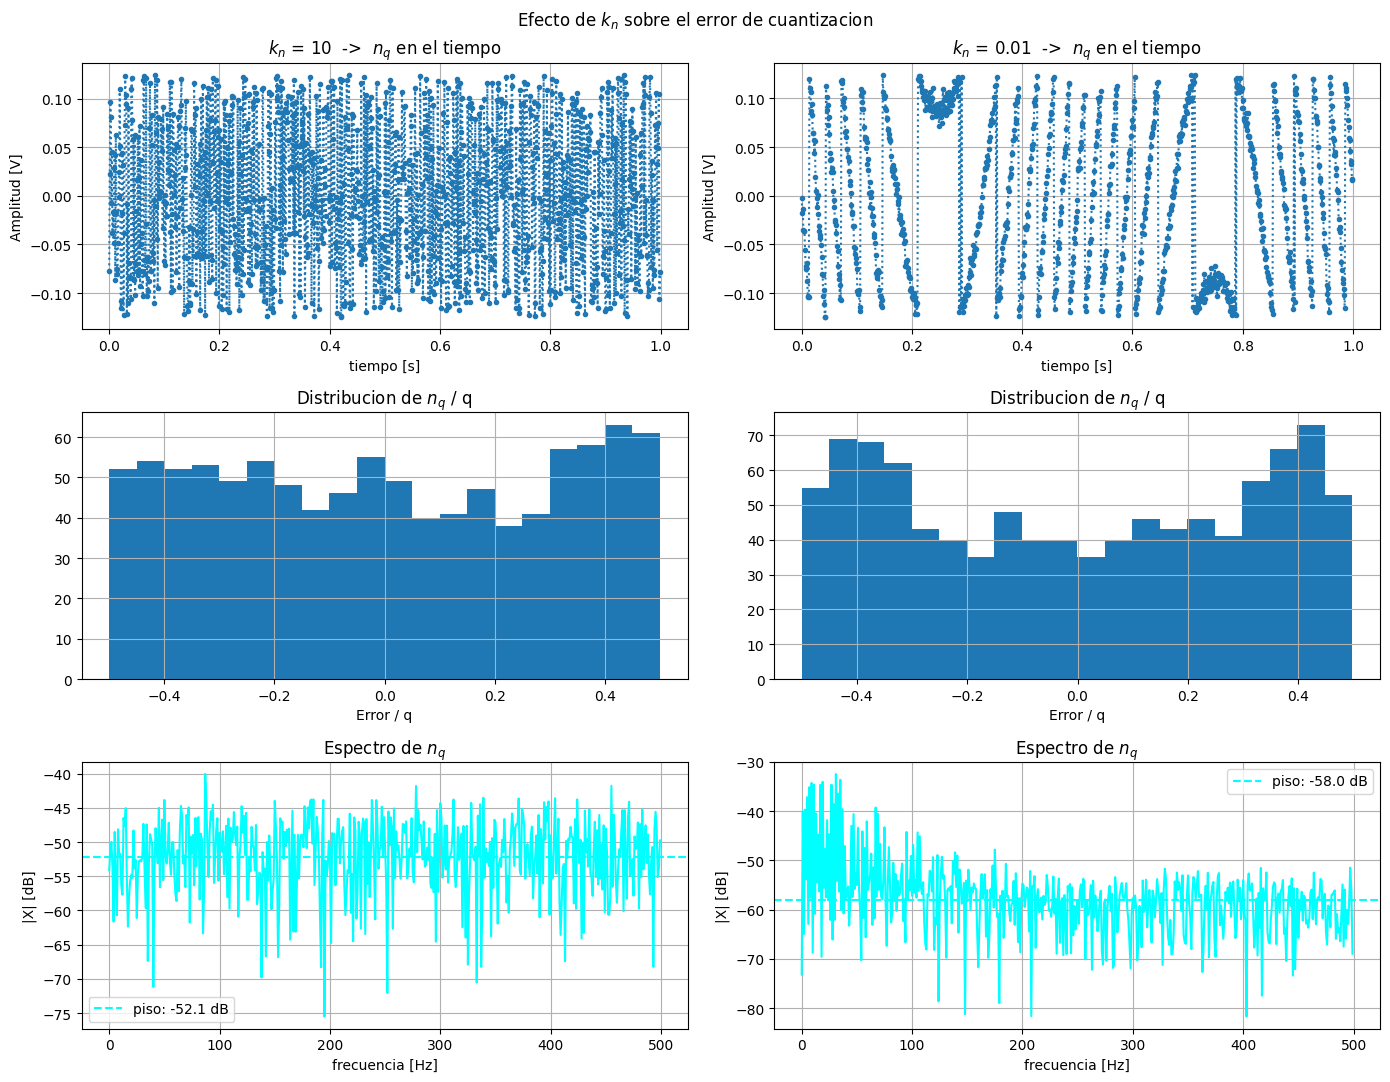

In [23]:
#%% --------------- COMPARACION k_n = 10 vs k_n = 1/100 ----------

def analisis_adc(k_n, n_bits=4, Vfs=2, nn=N, fs=fs):
    """Repite el analisis completo para un dado k_n. Devuelve (t, n_q, freq, n_q_dB)."""
    t, s = mi_funcion_seno(vmax=np.sqrt(2), ff=fs/nn, nn=nn, fs=fs)

    q = (2*Vfs)/(np.power(2, n_bits))
    sigma = np.sqrt(k_n * q**2/12)
    n = np.random.normal(scale=sigma, size=len(t))

    sn = s + n
    sn_q = np.round(sn/q)*q
    n_q = sn_q - sn

    freq, sn_abs = mi_fft(sn, fs)
    ref = np.max(sn_abs)
    freq, n_q_abs = mi_fft(n_q, fs)

    return t, n_q, q, freq, 20*np.log10(n_q_abs/ref)


fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle("Efecto de $k_n$ sobre el error de cuantizacion")

for col, k in enumerate([10, 1/100]):
    t_c, n_q_c, q_c, freq_c, n_q_dB_c = analisis_adc(k)

    axes[0, col].plot(t_c, n_q_c, ":.")
    axes[0, col].set_title("$k_n$ = {}  ->  $n_q$ en el tiempo".format(k))
    axes[0, col].set_xlabel("tiempo [s]")
    axes[0, col].set_ylabel("Amplitud [V]")
    axes[0, col].grid()

    axes[1, col].hist(n_q_c/q_c, bins=20)
    axes[1, col].set_title("Distribucion de $n_q$ / q")
    axes[1, col].set_xlabel("Error / q")
    axes[1, col].grid()

    axes[2, col].plot(freq_c, n_q_dB_c, color="cyan")
    axes[2, col].axhline(np.mean(n_q_dB_c), color="cyan", linestyle="--",
                         label="piso: {:.1f} dB".format(np.mean(n_q_dB_c)))
    axes[2, col].set_title("Espectro de $n_q$")
    axes[2, col].set_xlabel("frecuencia [Hz]")
    axes[2, col].set_ylabel("|X| [dB]")
    axes[2, col].legend()
    axes[2, col].grid()

    # cuanto se aparta n_q del modelo "blanco e incorrelado"
    r = np.correlate(n_q_c, n_q_c, "full"); r = r/np.max(r)
    mid = len(r)//2
    print("k_n = {:<6} | var(n_q)/(q^2/12) = {:.2f} | max|R[k!=0]| = {:.2f} | pico-piso = {:.1f} dB"
          .format(k, np.var(n_q_c)/(q_c**2/12), np.max(np.abs(r[mid+1:])),
                  np.max(n_q_dB_c) - np.mean(n_q_dB_c)))

plt.tight_layout()
plt.show()
